ESTE NOTEBOOK TIENE LA FINALIDAD DE EXPLICAR QUE ES EL TRUCO DEL KERNEL EN EL CONTEXTO DE SVM, REALIZANDO LOS CALCULOS DE MANERA EXPLICITA Y CONTRASTANDO CON LOS RESULTADOS DE LA LIBRERIA SKLEARN

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_circles
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import make_pipeline

El truco del kernel es una técnica que permite trabajar en espacios de alta (o infinita) dimensión sin tener que transformar explícitamente los datos a esos espacios, lo cual puede ser costoso o incluso imposible. En lugar de transformar los datos $x$ y $x'$ con una función $ \phi(x)$

calculamos directamente el producto interno  $ \phi(x) . \phi(x')$ mediante una función kernel $K(x,x')$


Usaremos el kernel polinomial como ejemplo: $K(x,x') = (x . x' + c)^d$

Este kernel corresponde a un mapeo implícito a un espacio de mayor dimensión.
Mostraremos que el producto interno en el espacio transformado se puede obtener directamente con el kernel.Trabajaremos en dos dimensiones con un valor de $d=2$





supongamos  $x = [x_1,x_2]$ y $x' = [x_1',x_2']$

queremos aplicar la transformación $\phi(x) = [x_1^2,\sqrt(2) x_1 x_2,x_2^2]$

Esta es una transformación explícita al espacio polinomial de grado 2 en 3 dimensiones.

Vamos a comparar:

$\phi(x) *\phi(x')$ que es el producto interno en el espacio transformado.

contra

$K(x,x') = (x . x')^2$ que es  el valor obtenido con el kernel polinomial

In [51]:
def dot_product(v1, v2): ### esto tal cual es un producto punto (x1,x2,x3)*(y1,y2,y3)= x1*y1 + x2*y2 + x3*y3
    return sum([a * b for a, b in zip(v1, v2)])

def explicit_phi(x): ### esta es la transformación explicita
    x1, x2 = x
    return [x1**2, (2**0.5) * x1 * x2, x2**2]

def kernel_polynomial(x, x_prime, degree=2, c=0): ### esto es el truco del kernel
    return (dot_product(x, x_prime) + c) ** degree

# Ejemplo
x = [1, 2]
x_prime = [3, 4]

# Producto interno explícito
phi_x = explicit_phi(x)
phi_x_prime = explicit_phi(x_prime)
dot_phi = dot_product(phi_x, phi_x_prime)

# Producto con kernel
kernel_val = kernel_polynomial(x, x_prime, degree=2, c=0)

print(f"Producto interno explícito: {dot_phi:.4f}")
print(f"Valor del kernel:           {kernel_val:.4f}")

Producto interno explícito: 121.0000
Valor del kernel:           121.0000


#### AHORA VEAMOS EL EJERCICIO USANDO MODELACIÓN

In [52]:
### CREAMOS UN CONJUNTO DE DATOS SINTETICOS PARA ILUSTRAR EL PROBLEMA
X, y = make_circles(n_samples=200, factor=0.5, noise=0.05, random_state=0)

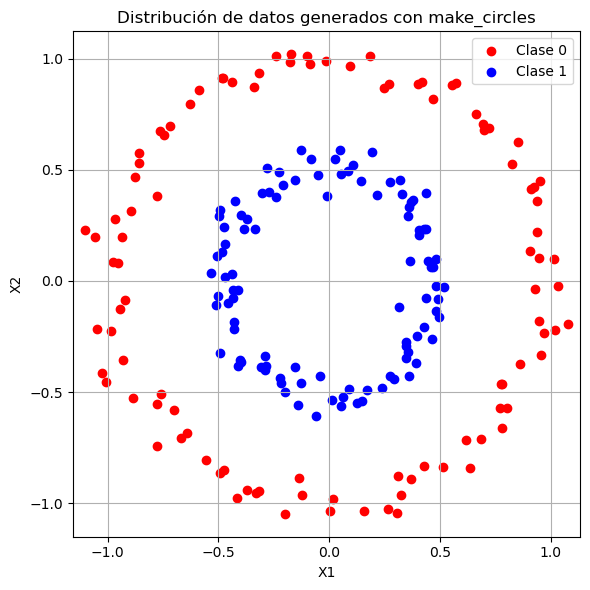

In [53]:
# GRAFICAMOS LOS DATOS ANTERIORMENTE CREADOS
plt.figure(figsize=(6, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Clase 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Clase 1')
plt.title('Distribución de datos generados con make_circles')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.grid(True)
plt.axis('equal')  # Mantiene la proporción de los ejes
plt.tight_layout()
plt.show()

In [54]:
# Definimos la transformación polinomial: phi(x) = [x1^2, sqrt(2)x1x2, x2^2]
def phi_manual(X):
    x1 = X[:, 0]
    x2 = X[:, 1]
    return np.vstack([
        x1**2,
        np.sqrt(2)*x1*x2,
        x2**2
    ]).T

# la aplicamos a los datos
X_phi = phi_manual(X)


In [55]:
X

array([[ 0.4013312 ,  0.88583093],
       [-0.14152176, -0.55959569],
       [ 0.40657379,  0.20692844],
       [ 0.96980084, -0.23250101],
       [ 0.06316851, -0.52396848],
       [ 0.23693493, -0.48112063],
       [ 0.93843314,  0.36100933],
       [-0.48546556,  0.12881606],
       [ 0.69925226,  0.67926227],
       [-0.45891757, -0.10041569],
       [-0.77742738, -0.74367   ],
       [-0.05150094,  0.47412741],
       [ 0.1474185 , -0.53935227],
       [-0.41021592, -0.04138111],
       [ 0.30902397, -0.8757646 ],
       [ 0.9100531 ,  0.41397713],
       [-0.44078192,  0.8964495 ],
       [-0.22642059,  0.4890907 ],
       [-0.71907726,  0.69489198],
       [-0.13840205, -0.88818218],
       [ 0.29293559, -0.43981514],
       [-0.47224619,  0.16779778],
       [-0.89346441,  0.31591914],
       [-0.42955424, -0.18372202],
       [-0.76042539, -0.50740155],
       [ 0.04981023,  0.58654824],
       [ 0.16896237, -0.48912039],
       [ 0.27503478, -0.42977338],
       [ 0.0255571 ,

In [56]:
X_phi

array([[ 1.61066734e-01,  5.02769315e-01,  7.84696437e-01],
       [ 2.00284098e-02,  1.11998600e-01,  3.13147337e-01],
       [ 1.65302243e-01,  1.18980162e-01,  4.28193796e-02],
       [ 9.40513664e-01, -3.18876407e-01,  5.40567175e-02],
       [ 3.99026004e-03, -4.68080727e-02,  2.74542968e-01],
       [ 5.61381603e-02, -1.61212259e-01,  2.31477058e-01],
       [ 8.80656752e-01,  4.79111685e-01,  1.30327739e-01],
       [ 2.35676807e-01, -8.84389190e-02,  1.65935768e-02],
       [ 4.88953722e-01,  6.71717040e-01,  4.61397226e-01],
       [ 2.10605331e-01,  6.51705324e-02,  1.00833114e-02],
       [ 6.04393329e-01,  8.17626752e-01,  5.53045074e-01],
       [ 2.65234699e-03, -3.45322780e-02,  2.24796798e-01],
       [ 2.17322131e-02, -1.12444828e-01,  2.90900870e-01],
       [ 1.68277098e-01,  2.40065448e-02,  1.71239639e-03],
       [ 9.54958171e-02, -3.82731809e-01,  7.66963631e-01],
       [ 8.28196642e-01,  5.32792477e-01,  1.71377068e-01],
       [ 1.94288703e-01, -5.58810558e-01

In [57]:
# Ajustamos un clasificador lineal con los datos transformados
clf_manual = LogisticRegression().fit(X_phi, y)

# Ajustamos un clasificador svm kernel polinomial (d=2, coef0=0)
clf_kernel = SVC(kernel='poly', degree=2, coef0=0, C=1.0).fit(X, y)

In [58]:
# Esta función grafica la frontera de decisión de un modelo de clasificación en 2D
def plot_decision_boundary(clf, X, y, transformer=None, title=""):
    #Calculamos los límites del gráfico (un poco más allá de los puntos de X)
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5

    # Creamos una malla de puntos (como un lienzo de 500x500)
    # Cada punto será evaluado por el modelo para ver de qué clase lo clasifica
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))

    # Convertimos esa malla en una lista de puntos 2D
    X_grid = np.c_[xx.ravel(), yy.ravel()]

    #print(len(X_grid))

    # Si estamos usando una transformación manual (por ejemplo, phi(x)), la aplicamos
    # Esto es útil cuando el modelo fue entrenado con una proyección explícita
    if transformer:
        X_grid_transformed = transformer(X_grid)
    else:
        X_grid_transformed = X_grid

    # El modelo predice la clase de cada punto en la malla
    # Esto nos dirá cómo "piensa" el modelo que se dividen las clases en todo el plano
    Z = clf.predict(X_grid_transformed).reshape(xx.shape)

    # Dibujamos las regiones coloreadas (fondo) según la clase que el modelo predice
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)

    # Sobre ese fondo, dibujamos los puntos reales del conjunto de datos
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')

    # Título y ajuste del gráfico
    plt.title(title)
    plt.axis('equal')  # Hace que los ejes tengan la misma escala (no se deformen los círculos)

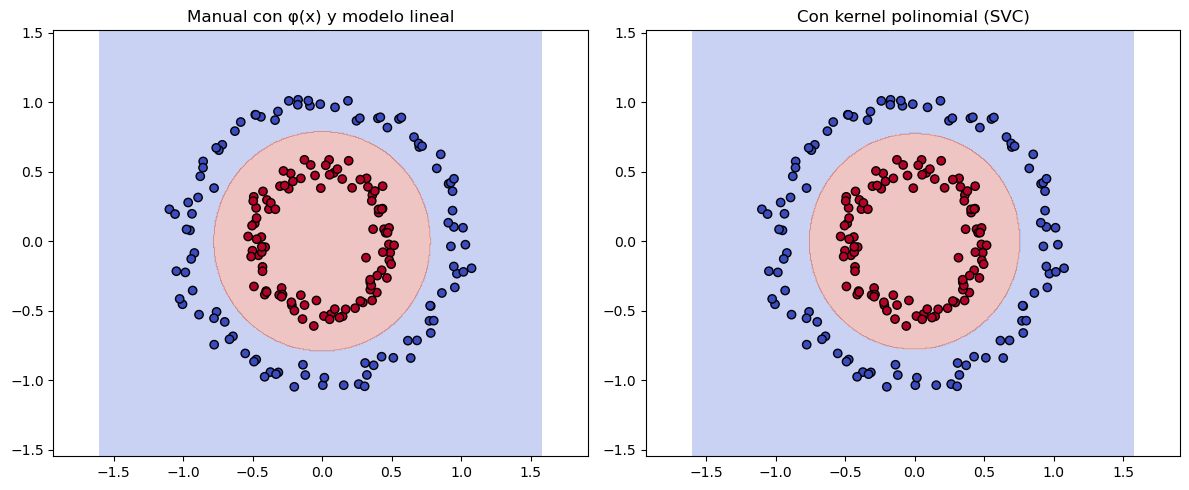

In [59]:
#Gráficos comparativos
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_decision_boundary(clf_manual, X, y, transformer=phi_manual, title="Manual con φ(x) y modelo lineal")

plt.subplot(1, 2, 2)
plot_decision_boundary(clf_kernel, X, y, transformer=None, title="Con kernel polinomial (SVC)")

plt.tight_layout()
plt.show()

En problemas reales, el truco del kernel nos evita tener que codificar 

ϕ(x), especialmente cuando el espacio es muy grande

### FINALMENTE VAMOS A REPLICAR MANUALMENTE LO QUE ESTÁ HACIENDO SVC

In [47]:
### SE DEFINE LA FUNCION DE KERNEL EXPLICITAMENTE PARA DOS DIMENSIONES
def polynomial_kernel(X1, X2, degree=2, coef0=0):
    return (X1 @ X2.T + coef0) ** degree

# CalculaMOS la matriz de kernel K para entrenamiento
K_train = polynomial_kernel(X, X)

# Entrenamos la maquina de soporte vectorial con un kernel precomputado, es decir, nosotros hacemos el calculo anteriormente
svc_precomputed = SVC(kernel='precomputed', C=1.0)
svc_precomputed.fit(K_train, y)

#Entrenamos el modelo con kernel='poly' como referencia
svc_builtin = SVC(kernel='poly', degree=2, coef0=0, C=1.0)
svc_builtin.fit(X, y)

# 6. Predicción y comparación en el conjunto de entrenamiento
y_pred_manual = svc_precomputed.predict(K_train)
y_pred_builtin = svc_builtin.predict(X)

print("¿Predicciones iguales?", np.all(y_pred_manual == y_pred_builtin))

¿Predicciones iguales? True


In [48]:
y_pred_manual

array([0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1], dtype=int64)

In [49]:
y_pred_builtin

array([0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1], dtype=int64)